In [1]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
file_path = r'D:\Python\VinUni\Data\retail-data-pipeline\data\raw\online_retail.xlsx'

df = pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


Text(0.5, 0, 'Attributes')

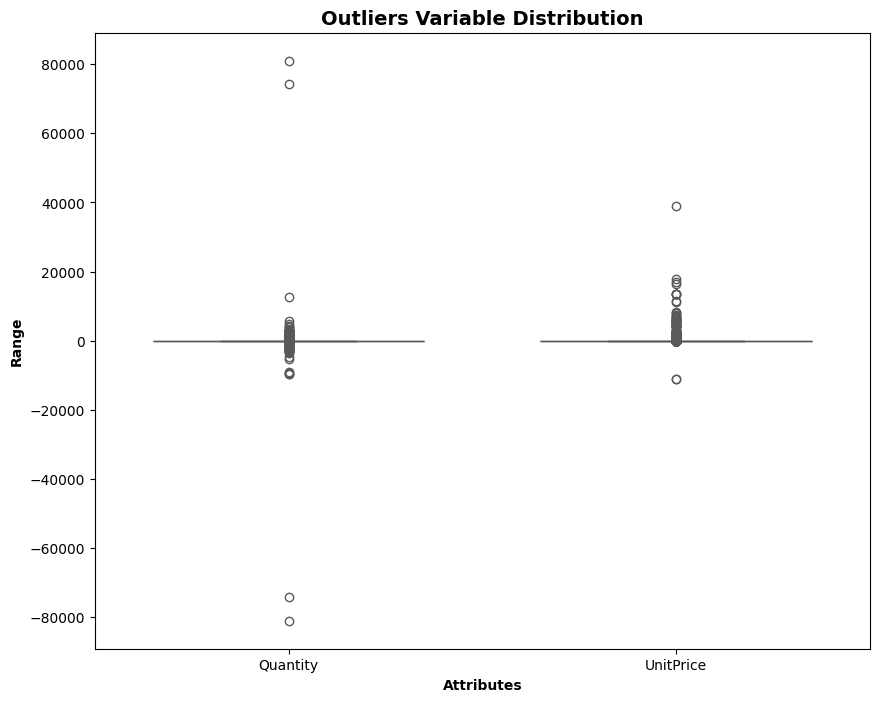

In [3]:
attributes = ['Quantity', 'UnitPrice']
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = df[attributes], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')

In [4]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [24]:
print(df.columns)
df.Country.unique()

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [3]:
# Bước 3: Làm sạch dữ liệu
# Xóa bỏ các khoảng trắng trong cột 'Description'
df['Description'] = df['Description'].str.strip()

# Xóa các hàng không có mã hóa đơn (InvoiceNo)
df.dropna(axis = 0, subset =['InvoiceNo'], inplace = True) 
df['InvoiceNo'] = df['InvoiceNo'].astype('str')

# Xóa các giao dịch thực hiện bằng thẻ tín dụng (Credit)
df = df[~df['InvoiceNo'].str.contains('C')]


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532621 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    532621 non-null  object        
 1   StockCode    532621 non-null  object        
 2   Description  531166 non-null  object        
 3   Quantity     532621 non-null  int64         
 4   InvoiceDate  532621 non-null  datetime64[ns]
 5   UnitPrice    532621 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      532621 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.6+ MB


In [4]:
# Bước 4: Phân tích dữ liệu
# Giao dịch thực hiện tại Pháp
France = (df[df['Country'] =="France"] 
		.groupby(['InvoiceNo', 'Description'])['Quantity'] 
		.sum().unstack().reset_index().fillna(0) 
		.set_index('InvoiceNo'))

# Giao dịch thực hiện tại Anh 
UK = (df[df['Country'] =="United Kingdom"] 
		.groupby(['InvoiceNo', 'Description'])['Quantity'] 
		.sum().unstack().reset_index().fillna(0) 
		.set_index('InvoiceNo')) 

# Giao dịch thực hiện tại Bồ Đào Nha 
Por = (df[df['Country'] =="Portugal"] 
		.groupby(['InvoiceNo', 'Description'])['Quantity'] 
		.sum().unstack().reset_index().fillna(0) 
		.set_index('InvoiceNo')) 

# Giao dịch thực hiện tại Thụy Điển
Sweden = (df[df['Country'] =="Sweden"] 
		.groupby(['InvoiceNo', 'Description'])['Quantity'] 
		.sum().unstack().reset_index().fillna(0) 
		.set_index('InvoiceNo')) 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532621 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    532621 non-null  object        
 1   StockCode    532621 non-null  object        
 2   Description  531166 non-null  object        
 3   Quantity     532621 non-null  int64         
 4   InvoiceDate  532621 non-null  datetime64[ns]
 5   UnitPrice    532621 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      532621 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.6+ MB


In [13]:
print(France.head(10))  # Hiển thị 10 luật đầu tiên

Description  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
InvoiceNo                                                         
536370                            0                           0   
536852                            0                           0   
536974                            0                           0   
537065                            0                           0   
537463                            0                           0   
537468                            1                           0   
537693                            0                           0   
537897                            0                           0   
537967                            0                           0   
538008                            0                           0   

Description  12 EGG HOUSE PAINTED WOOD  12 MESSAGE CARDS WITH ENVELOPES  \
InvoiceNo                                                                 
536370                               0       

In [6]:
# Bước 5: Chuyển đổi dữ liệu thành định dạng thích hợp cho thư viện mlxtend
# Chuyển đổi dữ liệu thành định dạng thích hợp cho thư viện mlxtend
def hot_encode(x): 
	if(x<= 0): 
		return 0
	if(x>= 1): 
		return 1

# Mã hóa dữ liệu 
basket_encoded = France.applymap(hot_encode) 
France = basket_encoded 

basket_encoded = UK.applymap(hot_encode) 
UK = basket_encoded 

basket_encoded = Por.applymap(hot_encode) 
Por = basket_encoded 

basket_encoded = Sweden.applymap(hot_encode) 
Sweden = basket_encoded 


C:\Users\Van Quyet\AppData\Local\Temp\ipykernel_14296\1272832951.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = France.applymap(hot_encode)
C:\Users\Van Quyet\AppData\Local\Temp\ipykernel_14296\1272832951.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = UK.applymap(hot_encode)
C:\Users\Van Quyet\AppData\Local\Temp\ipykernel_14296\1272832951.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = Por.applymap(hot_encode)
C:\Users\Van Quyet\AppData\Local\Temp\ipykernel_14296\1272832951.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = Sweden.applymap(hot_encode)


In [7]:
print(France.head(10))

Description  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
InvoiceNo                                                         
536370                            0                           0   
536852                            0                           0   
536974                            0                           0   
537065                            0                           0   
537463                            0                           0   
537468                            1                           0   
537693                            0                           0   
537897                            0                           0   
537967                            0                           0   
538008                            0                           0   

Description  12 EGG HOUSE PAINTED WOOD  12 MESSAGE CARDS WITH ENVELOPES  \
InvoiceNo                                                                 
536370                               0       

In [10]:
print(France.head(10))  # Hiển thị 10 dòng đầu tiên

Description  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
InvoiceNo                                                         
536370                            0                           0   
536852                            0                           0   
536974                            0                           0   
537065                            0                           0   
537463                            0                           0   
537468                            1                           0   
537693                            0                           0   
537897                            0                           0   
537967                            0                           0   
538008                            0                           0   

Description  12 EGG HOUSE PAINTED WOOD  12 MESSAGE CARDS WITH ENVELOPES  \
InvoiceNo                                                                 
536370                               0       

In [11]:
print(UK.head(10))  # Hiển thị 10 dòng đầu tiên

Description  *Boombox Ipod Classic  *USB Office Mirror Ball  \
InvoiceNo                                                     
536365                           0                        0   
536366                           0                        0   
536367                           0                        0   
536368                           0                        0   
536369                           0                        0   
536371                           0                        0   
536372                           0                        0   
536373                           0                        0   
536374                           0                        0   
536375                           0                        0   

Description  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
InvoiceNo                                                         
536365                            0                           0   
536366                            0       

In [12]:
print(Por.head(10))  # Hiển thị 10 dòng đầu tiên

Description  10 COLOUR SPACEBOY PEN  12 PENCIL SMALL TUBE WOODLAND  \
InvoiceNo                                                            
536990                            0                              0   
537246                            0                              0   
537818                            0                              0   
537915                            0                              0   
538311                            0                              0   
539353                            0                              0   
540519                            0                              0   
540546                            1                              0   
541430                            0                              0   
542147                            0                              0   

Description  12 PENCILS SMALL TUBE RED RETROSPOT  12 PENCILS TALL TUBE POSY  \
InvoiceNo                                                                     
5

In [15]:
# Building the model 
frq_items = apriori(France, min_support = 0.05, use_colnames = True) 

# Collecting the inferred rules in a dataframe 
rules = association_rules(frq_items, metric ="lift", min_threshold = 1) 
rules = rules.sort_values(['confidence', 'lift'], ascending =[False, False]) 
print(rules.head()) 

d:\python\AI\envs\aio2024_env\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


                                           antecedents  \
44                        (JUMBO BAG WOODLAND ANIMALS)   
259  (PLASTERS IN TIN CIRCUS PARADE, RED TOADSTOOL ...   
271  (PLASTERS IN TIN WOODLAND ANIMALS, RED TOADSTO...   
301  (SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...   
302  (SET/6 RED SPOTTY PAPER PLATES, SET/20 RED RET...   

                         consequents  antecedent support  consequent support  \
44                         (POSTAGE)            0.076531            0.765306   
259                        (POSTAGE)            0.051020            0.765306   
271                        (POSTAGE)            0.053571            0.765306   
301  (SET/6 RED SPOTTY PAPER PLATES)            0.102041            0.127551   
302    (SET/6 RED SPOTTY PAPER CUPS)            0.102041            0.137755   

      support  confidence      lift  representativity  leverage  conviction  \
44   0.076531       1.000  1.306667               1.0  0.017961         inf   
259  0.05102

In [16]:
frq_items = apriori(UK, min_support = 0.01, use_colnames = True, max_len=2) 
rules = association_rules(frq_items, metric ="lift", min_threshold = 1) 
rules = rules.sort_values(['confidence', 'lift'], ascending =[False, False]) 
print(rules.head()) 

d:\python\AI\envs\aio2024_env\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


MemoryError: Unable to allocate 87.1 GiB for an array with shape (313236, 2, 18667) and data type int64